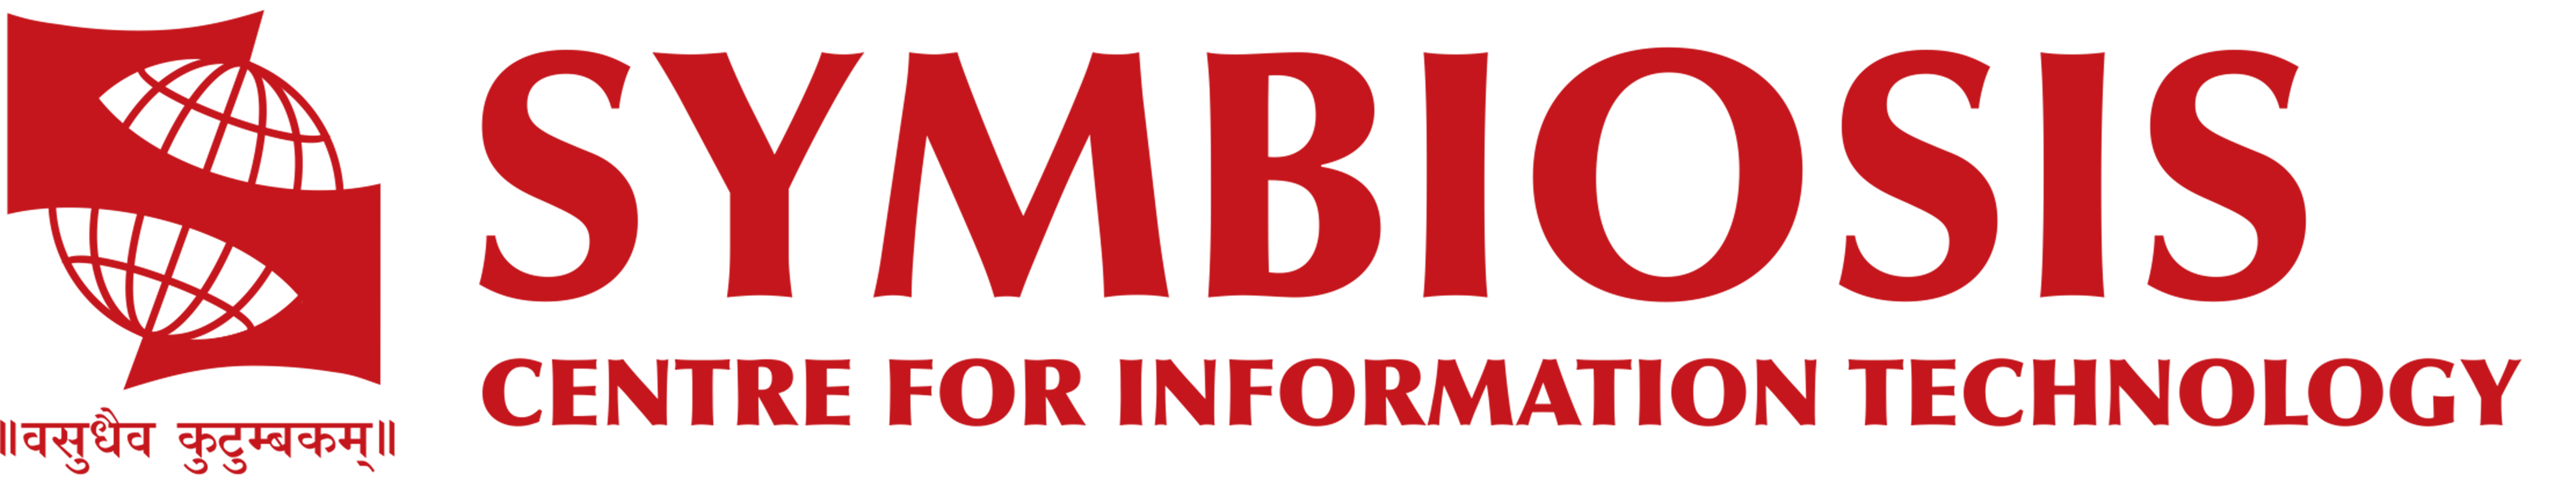

In [1]:
from IPython.display import Image, display

display(Image("/Users/sadanandyadav/Desktop/Group 2 BFM IT SOFTWARE/Report/StaticResources/RegisteredResources/SCIT_new_logo_1_(1)22360125436082812.png"))

## Project Team Members

| NAME           | PRN    |
|---------------|--------|
| Sadanand      | 25030241038 |
| Riyanshi Vasoya  | 25030241054 |
| Harsh vardhan    | 25030241019 |
| Anushka Srivastava | 25030241005 |
| Khushi Shaikh   | 25030241023 |

In [2]:
# Imports libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, r2_score

In [3]:
# Read Dataset
df = pd.read_csv(
    "/Users/sadanandyadav/Desktop/Semester 2 Notes/Business Analytics/Assignment/Anonymize_Loan_Default_data.csv",
    encoding="ISO-8859-1"
)
df.head().style.background_gradient(cmap='viridis')

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,repay_fail
0,2,2,2,0.000000,0.000000,0.000000,36 months,0.000000,0.000000,< 1 year,RENT,0.000000,Not Verified,Dec-99,Charged Off,major_purchase,000xx,ZZ,0.000000,0.000000,Jan-01,0.000000,nan,0.000000,0.000000,0.000000,0.00%,1.000000,0.000000,0.000000,0.000000,0.000000,Jan-07,0.000000,Jan-07,Jan-07,1
1,3,545583,703644,2500.000000,2500.000000,2500.000000,36 months,13.980000,85.420000,4 years,RENT,20004.000000,Not Verified,Jul-10,Does not meet the credit policy. Status:Fully Paid,other,487xx,MI,19.860000,0.000000,Aug-05,5.000000,nan,7.000000,0.000000,981.000000,21.30%,10.000000,3075.291779,3075.290000,2500.000000,575.290000,Jul-13,90.850000,Aug-13,Jun-16,0
2,4,532101,687836,5000.000000,5000.000000,5000.000000,36 months,15.950000,175.670000,4 years,RENT,59000.000000,Not Verified,Jun-10,Charged Off,debt_consolidation,115xx,NY,19.570000,0.000000,Apr-94,1.000000,59.000000,7.000000,0.000000,18773.000000,99.90%,15.000000,2948.760000,2948.760000,1909.020000,873.810000,Nov-11,175.670000,nan,Mar-12,1
3,5,877788,1092507,7000.000000,7000.000000,7000.000000,36 months,9.910000,225.580000,10+ years,MORTGAGE,53796.000000,Not Verified,Sep-11,Fully Paid,other,751xx,TX,10.800000,3.000000,Mar-98,3.000000,3.000000,7.000000,0.000000,3269.000000,47.20%,20.000000,8082.391880,8082.390000,7000.000000,1082.390000,Mar-14,1550.270000,nan,Mar-14,0
4,6,875406,1089981,2000.000000,2000.000000,2000.000000,36 months,5.420000,60.320000,10+ years,RENT,30000.000000,Not Verified,Sep-11,Fully Paid,debt_consolidation,112xx,NY,3.600000,0.000000,Jan-75,0.000000,72.000000,7.000000,0.000000,0.000000,0%,15.000000,2161.663244,2161.660000,2000.000000,161.660000,Feb-14,53.120000,nan,Jun-16,0


In [4]:
# checking 
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 38480, Columns: 37


In [5]:
df.describe().style.background_gradient(cmap="viridis")


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,total_acc,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,last_pymnt_amnt,repay_fail
count,38480.000000,38480.000000,38480.000000,38479.000000,38479.000000,38479.000000,38480.000000,38479.000000,38478.000000,38480.000000,38479.000000,38479.000000,14117.000000,38479.000000,38479.000000,38476.000000,38479.000000,38479.000000,38479.000000,38479.000000,38479.000000,38479.000000,38480.000000
mean,19240.500000,664997.930016,826189.854288,11094.727644,10831.856337,10150.141518,12.164300,323.163255,68995.308917,13.378119,0.151927,1.083942,35.009846,9.342966,0.057902,14289.866280,22.108501,11980.696892,11274.519569,9646.412705,2232.768235,2614.441757,0.151481
std,11108.363516,219232.159934,279353.137600,7405.416042,7146.853682,7128.026828,3.737440,209.089097,64476.388744,6.744356,0.507592,1.534814,22.426843,4.498075,0.245707,21941.377270,11.588602,9006.505205,8946.229941,7051.828302,2570.177312,4391.969583,0.358522
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9620.750000,498364.500000,638462.000000,5200.000000,5100.000000,4950.000000,9.620000,165.740000,40000.000000,8.200000,0.000000,0.000000,17.000000,6.000000,0.000000,3639.750000,13.000000,5463.099238,4811.735000,4400.000000,657.700000,212.010000,0.000000
50%,19240.500000,644319.500000,824254.500000,9750.000000,9600.000000,8495.792749,11.990000,277.980000,58650.000000,13.485000,0.000000,1.000000,33.000000,9.000000,0.000000,8839.500000,20.000000,9673.221341,8953.240000,8000.000000,1335.090000,526.000000,0.000000
75%,28860.250000,826560.750000,1034706.500000,15000.000000,15000.000000,14000.000000,14.720000,429.350000,82000.000000,18.690000,0.000000,2.000000,51.000000,12.000000,0.000000,17265.500000,29.000000,16402.394995,15486.925000,13315.100000,2795.020000,3169.815000,0.000000
max,38480.000000,1077430.000000,1314167.000000,35000.000000,35000.000000,35000.000000,100.990000,1305.190000,6000000.000000,100.000000,11.000000,33.000000,120.000000,47.000000,5.000000,1207359.000000,90.000000,58563.679930,58563.680000,35000.020000,23611.100000,36115.200000,1.000000


# Variable Description

## 🔹 Identifier Variables

- **id**: Unique identifier for each loan record.  
- **member_id**: Unique identifier for the borrower associated with the loan.

## 🔹 Loan Details

- **loan_amnt**: Amount of the loan requested by the borrower.  
- **funded_amnt**: Actual amount of the loan funded by the lender.  
- **funded_amnt_inv**: Portion of the loan funded by investors.  
- **term**: Duration of the loan, typically expressed in months.  
- **int_rate**: Interest rate applied to the loan (percentage).  
- **installment**: Monthly payment amount owed by the borrower.


## 🔹 Employment & Income Information

- **emp_length**: Length of the borrower’s employment.  
- **home_ownership**: Borrower’s home ownership status (RENT, OWN, MORTGAGE, etc.).  
- **annual_inc**: Annual income of the borrower.  
- **verification_status**: Indicates whether the borrower’s income was verified.


## 🔹 Loan Context & Purpose

- **issue_d**: Date when the loan was issued.  
- **loan_status**: Current status of the loan (Current, Fully Paid, Charged Off, etc.).  
- **purpose**: Purpose for which the loan was requested.  
- **title**: Title provided by the borrower describing the loan request.


## 🔹 Geographic Information

- **zip_code**: First three digits of the borrower’s ZIP code.  
- **addr_state**: State of residence of the borrower.


## 🔹 Credit & Risk Indicators

- **dti**: Debt-to-Income ratio (total monthly debt / gross monthly income).  
- **delinq_2yrs**: Number of delinquent accounts (30+ days past due) in the last two years.  
- **earliest_cr_line**: Date when the borrower’s earliest credit line was opened.  
- **inq_last_6mths**: Number of credit inquiries in the past six months.  
- **open_acc**: Number of open credit accounts.  
- **pub_rec**: Number of derogatory public records (bankruptcies, tax liens, etc.).  
- **revol_bal**: Total outstanding revolving credit balance.  
- **revol_util**: Revolving credit utilization rate (% of available credit used).  
- **total_acc**: Total number of credit lines in the borrower’s credit history.

## 🔹 Payment History (Post-Loan Information)

- **total_pymnt**: Total amount paid by the borrower to date.  
- **total_pymnt_inv**: Total amount paid to investors to date.  
- **total_rec_prncp**: Total principal repaid.  
- **total_rec_int**: Total interest paid.  
- **last_pymnt_d**: Date of the most recent payment.  
- **last_pymnt_amnt**: Amount of the most recent payment.  
- **next_pymnt_d**: Next scheduled payment date.  
- **last_credit_pull_d**: Most recent date when the credit report was pulled.

## 🎯 Target Variable

- **repay_fail**: Binary target variable indicating loan repayment failure  
  - **0** → No default  
  - **1** → Default occurred


In [6]:
# Create a summary table to understand dataset structure and quality
pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values
}).style.background_gradient(cmap="Blues")


,Column,Data Type,Missing Values
0,Unnamed: 0,int64,0
1,id,int64,0
2,member_id,int64,0
3,loan_amnt,float64,1
4,funded_amnt,float64,1
5,funded_amnt_inv,float64,1
6,term,object,0
7,int_rate,float64,0
8,installment,float64,1
9,emp_length,object,993


# Data Transformation

In [7]:
# --------------------------------------------------
# Create a copy of the original dataset
# --------------------------------------------------
# This ensures the raw data remains unchanged
df_clean = df.copy()


In [8]:
# List of columns that contain a small number of missing values
small_missing_cols = [
    'loan_amnt','funded_amnt','funded_amnt_inv','installment',
    'annual_inc','delinq_2yrs','inq_last_6mths',
    'open_acc','pub_rec','revol_bal','total_acc',
    'total_pymnt','total_pymnt_inv','total_rec_prncp','last_credit_pull_d','last_pymnt_d','revol_util','emp_length',
    'total_rec_int','last_pymnt_amnt'
]


In [9]:
# Identify rows that contain at least one missing value 
rows_with_small_missing = df_clean[df_clean[small_missing_cols].isna().any(axis=1)]
rows_with_small_missing.shape


(1121, 37)

In [10]:
# Display the first 10 rows where small-missing columns have NaN values
# along with the target variable 'repay_fail' for analysis
rows_with_small_missing[
    small_missing_cols + ['repay_fail']
].head(10)


,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,...,total_pymnt,total_pymnt_inv,total_rec_prncp,last_credit_pull_d,last_pymnt_d,revol_util,emp_length,total_rec_int,last_pymnt_amnt,repay_fail
6,8000.0,8000.0,8000.00000,243.49,77736.0,0.0,0.0,12.0,0.0,4182.0,...,8724.971815,8724.97,8000.00,Apr-14,Apr-14,13.60%,NaN,724.97,1423.66,0
36,1450.0,1450.0,1450.00000,45.12,10000.0,0.0,0.0,9.0,0.0,709.0,...,1555.993411,1555.99,1450.00,Dec-11,Dec-11,3.20%,NaN,105.99,970.62,0
50,35000.0,35000.0,28825.00602,961.50,73000.0,3.0,1.0,8.0,0.0,19505.0,...,12320.780000,10145.25,2787.92,Jun-12,Jan-12,97.50%,NaN,4894.00,961.50,1
54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Jan-99,Jan-99,100.00%,10+ years,NaN,NaN,0
67,1800.0,1800.0,1800.00000,54.29,29184.0,0.0,2.0,7.0,0.0,30037.0,...,1947.208326,1947.21,1800.00,Jan-15,Oct-13,23.50%,NaN,147.21,49.34,0
144,4000.0,4000.0,4000.00000,128.38,35000.0,0.0,2.0,6.0,1.0,1180.0,...,4600.818715,4600.82,4000.00,Nov-13,Nov-13,8.40%,NaN,600.82,883.45,0
162,10000.0,10000.0,9950.00000,310.10,50000.0,0.0,0.0,12.0,0.0,8613.0,...,10856.677280,10802.39,10000.00,Jun-16,Feb-13,29.60%,NaN,856.68,2851.52,0
171,4000.0,4000.0,4000.00000,142.99,37200.0,0.0,0.0,6.0,0.0,4598.0,...,458.180000,458.18,172.26,Mar-15,Apr-10,57.50%,NaN,113.12,142.99,1
176,5000.0,5000.0,4975.00000,108.69,22992.0,1.0,0.0,4.0,0.0,6201.0,...,6289.920000,6258.50,4776.45,Jun-16,Jun-16,18.80%,NaN,1513.47,108.69,0
226,2250.0,2250.0,2225.00000,67.86,52500.0,0.0,0.0,9.0,0.0,4425.0,...,2442.289367,2415.15,2250.00,Mar-16,Feb-14,36%,NaN,192.29,208.76,0


In [11]:
"""Remove rows that contain missing values 
in any of the columns listed in 'small_missing_cols'"""
df_clean = df_clean.dropna(subset=small_missing_cols)


In [12]:
# Identify logically inconsistent records in the dataset
 # Borrower has reported at least one delinquency in the last 2 years
 # But the months since last delinquency is missing
inconsistent_rows = df_clean[
    (df_clean['delinq_2yrs'] > 0) &
    (df_clean['mths_since_last_delinq'].isna())
]


In [13]:
# Display selected columns from the inconsistent records
# to inspect the logical issue more clearly
inconsistent_rows[
    ['delinq_2yrs', 'mths_since_last_delinq', 'repay_fail']
].head(10)


,delinq_2yrs,mths_since_last_delinq,repay_fail


In [14]:
# Replace missing values in 'mths_since_last_delinq'
# with 999 to indicate "No delinquency history / Not applicable"
df_clean['mths_since_last_delinq'] = (
    df_clean['mths_since_last_delinq'].fillna(999)
)


In [15]:
# Create a structured summary table for the cleaned dataset (df_clean)
pd.DataFrame({
    "Column": df_clean.columns,
    "Data Type": df_clean.dtypes.values,
    "Missing Values": df_clean.isnull().sum().values
}).style.background_gradient(cmap="Blues")


,Column,Data Type,Missing Values
0,Unnamed: 0,int64,0
1,id,int64,0
2,member_id,int64,0
3,loan_amnt,float64,0
4,funded_amnt,float64,0
5,funded_amnt_inv,float64,0
6,term,object,0
7,int_rate,float64,0
8,installment,float64,0
9,emp_length,object,0


In [16]:
# Check for invalid or suspicious interest rates (<= 0)
# and view their relationship with the target variable
df_clean.loc[df_clean['int_rate'] <= 0, ['int_rate', 'repay_fail']].head(10)


,int_rate,repay_fail
0,0.0,1


In [17]:
# Remove rows where interest rate is less than or equal to 0
# (Since valid loan interest rates must be positive)
df_clean = df_clean[df_clean['int_rate'] > 0]


In [18]:
# Re-check for any invalid interest rate values (<= 0)
# This acts as a validation step after cleaning
df_clean.loc[df_clean['int_rate'] <= 0, ['int_rate', 'repay_fail']].head(10)

,int_rate,repay_fail


In [19]:
# List of features that must strictly have positive values
# (Financial variables that logically cannot be zero or negative)
strict_positive = [
    'loan_amnt','funded_amnt','funded_amnt_inv',
    'installment','annual_inc','int_rate'
]

(df_clean[strict_positive] <= 0).sum()


loan_amnt            0
funded_amnt          0
funded_amnt_inv    198
installment          0
annual_inc           0
int_rate             0
dtype: int64

In [20]:
# List of features that should be non-negative
# (They can be zero, but should never be negative)

non_negative = [
    'dti','delinq_2yrs','inq_last_6mths','open_acc',
    'pub_rec','revol_bal','total_acc','mths_since_last_delinq'
]

(df_clean[non_negative] < 0).sum()


dti                       0
delinq_2yrs               0
inq_last_6mths            0
open_acc                  0
pub_rec                   0
revol_bal                 0
total_acc                 0
mths_since_last_delinq    0
dtype: int64

In [21]:
# Clean and convert 'revol_util' (Revolving Utilization Rate) 
# from percentage string format (e.g., "45%") to numeric float (e.g., 45.0)
df_clean['revol_util'] = (
    df_clean['revol_util']
    .str.replace('%', '', regex=False)
    .astype(float)
)


In [22]:
# Check for invalid values in 'revol_util'
# Revolving utilization should logically be between 0 and 100
(df_clean['revol_util'] < 0).sum(), (df_clean['revol_util'] > 100).sum()


(np.int64(0), np.int64(23))

In [23]:
# Cap (limit) the upper bound of 'revol_util' at 100
# Any value greater than 100 will be replaced with 100
df_clean['revol_util'] = df_clean['revol_util'].clip(upper=100)


In [24]:
# Final validation check for 'revol_util' after clipping
(df_clean['revol_util'] < 0).sum(), (df_clean['revol_util'] > 100).sum()


(np.int64(0), np.int64(0))

In [25]:
# Check for duplicate rows in the cleaned dataset
df_clean.duplicated().sum()


np.int64(0)

# EDA

In [26]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
# Set overall Seaborn theme for consistent, clean visuals
sns.set_theme(
    style="whitegrid",
    palette="muted",
    font_scale=1.1
)
# Remove unnecessary top and right borders (spines)
# This gives a cleaner, modern dashboard-style appearance
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


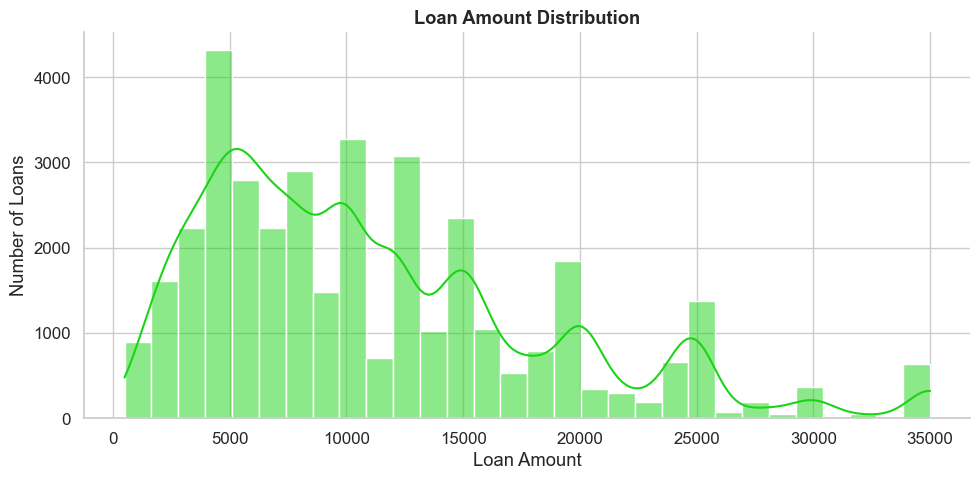

In [27]:
# Create Loan distribution Chart
plt.figure(figsize=(10,5))
sns.histplot(
    df_clean['loan_amnt'],
    bins=30,
    kde=True,
    color="#1BD415"
)

plt.title("Loan Amount Distribution", weight="bold")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")
plt.tight_layout()
plt.show()


### 📊 Loan Amount Distribution

This visualization represents the distribution of loan amounts in the dataset.

- A histogram is used to show the frequency of loan amounts.
- 30 bins are applied to capture the spread of values.
- A Kernel Density Estimate (KDE) curve is added to visualize the smooth distribution trend.
- The chart helps identify:
  - Common loan amount ranges
  - Skewness in the data
  - Presence of high-value outliers

#### 🎯 Analytical Insight
Loan datasets typically show a right-skewed distribution, where:
- Most borrowers take moderate loan amounts.
- A smaller number of borrowers take very high loan amounts.

Understanding this distribution is important for:
- Risk segmentation
- Feature engineering
- Detecting outliers before model training

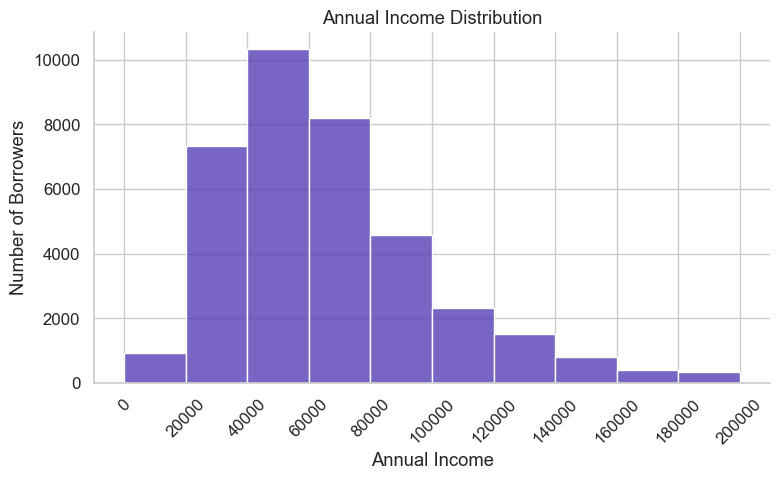

In [28]:
# Create Annual Income distribution chart
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define bins: 0–10k, 10–20k, ..., 200k
bins = np.arange(0, 220000, 20000)
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean['annual_inc'],
    bins=bins,
    color="#4C32B0"
)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Borrowers")

plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()


### 📊 Annual Income Distribution

This histogram shows how borrowers' annual incomes are distributed across defined income ranges (in ₹20,000 intervals).

#### Key Insights:
- Most borrowers fall within lower to middle income brackets.
- The distribution is typically right-skewed.
- High-income values may represent outliers.

#### Why It Matters:
Annual income is a critical factor in assessing repayment capacity and overall credit risk.

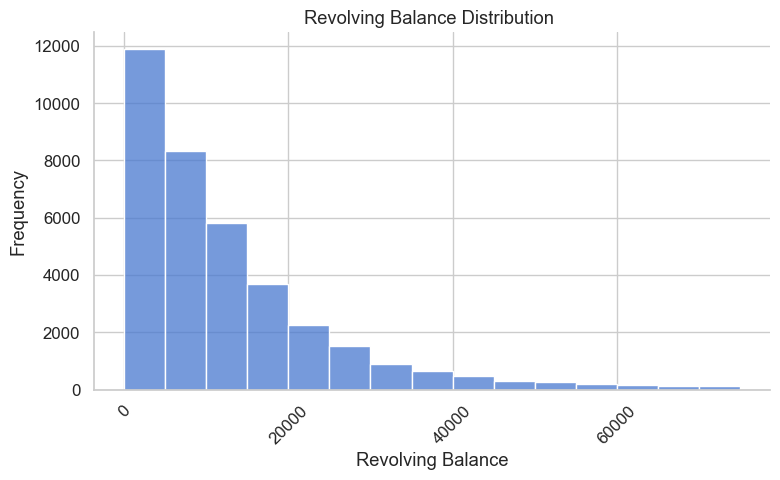

In [29]:
# Check Revolving Balance distribution
rev_bins = np.arange(0, 80000, 5000)

plt.figure(figsize=(8,5))
sns.histplot(df_clean['revol_bal'], bins=rev_bins)

plt.title("Revolving Balance Distribution ")
plt.xlabel("Revolving Balance")
plt.ylabel("Frequency")

plt.xticks(rev_bins[::4], rotation=45)
plt.tight_layout()
plt.show()


### 📊 Revolving Balance Distribution

This histogram shows the distribution of borrowers' revolving credit balances using ₹5,000 intervals.

#### Key Insights:
- Most borrowers have lower revolving balances.
- The distribution is typically right-skewed.
- High balance values may indicate higher credit utilization and potential risk.

#### Why It Matters:
Revolving balance reflects existing credit exposure and plays a crucial role in assessing borrower risk.

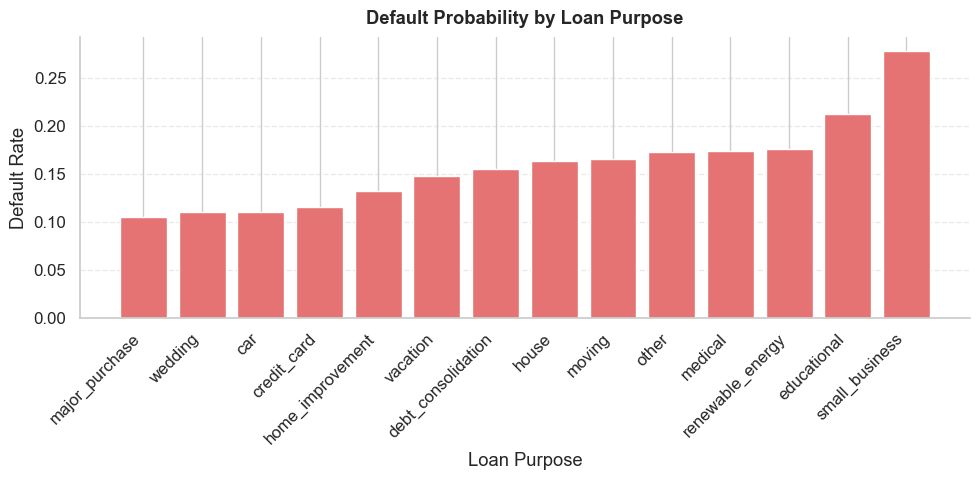

In [30]:
# Plot Default Probability By loan purpose
purpose_default = (
    df.groupby('purpose')['repay_fail']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))
bars = plt.bar(
    purpose_default.index,
    purpose_default.values,
    color="#E57373",          # softer red
    edgecolor="white",
    linewidth=1
)

plt.title("Default Probability by Loan Purpose", weight="bold", pad=10)
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### 📊 Default Probability by Loan Purpose

This bar chart shows the average default rate (`repay_fail`) across different loan purposes.

#### Key Insights:
- Loan purposes are ranked from lowest to highest default probability.
- Certain purposes may exhibit significantly higher default risk.
- Purpose-based risk variation helps in borrower segmentation.

#### Why It Matters:
Loan purpose is an important behavioral indicator in credit risk modeling.  
It helps lenders adjust underwriting policies, pricing strategies, and risk controls based on category-level default trends.

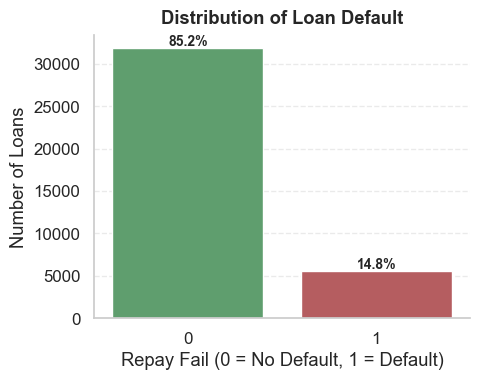

In [31]:
# Check distribution of Loan default
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df_clean,
    x='repay_fail',
    hue='repay_fail',                  # <-- explicit hue
    palette={0: "#55A868", 1: "#C44E52"},
    legend=False
)

total = len(df_clean)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Distribution of Loan Default", weight="bold", pad=8)
plt.xlabel("Repay Fail (0 = No Default, 1 = Default)")
plt.ylabel("Number of Loans")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


### 📊 Distribution of Loan Default

This count plot shows the number and percentage of loans that resulted in default (`repay_fail = 1`) versus non-default (`repay_fail = 0`).

#### Key Insights:
- Displays both absolute counts and percentage share.
- Helps identify class imbalance in the dataset.
- Visual percentage labels improve interpretability.

#### Why It Matters:
Understanding class distribution is critical before model training.  
If the dataset is imbalanced, techniques like resampling, class weights, or evaluation metric adjustments may be required.

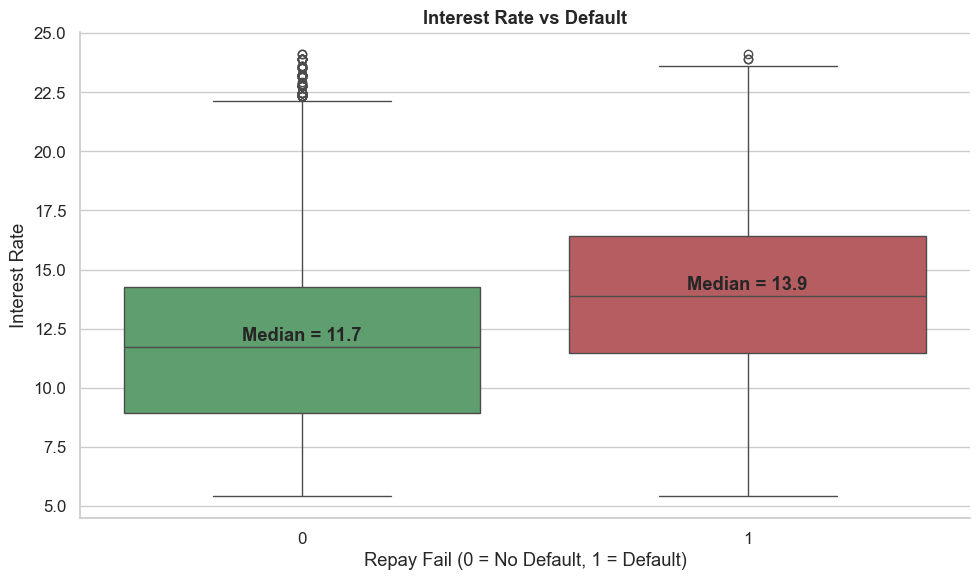

In [32]:
# Check relation between interest rate and default 
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='repay_fail',
    y='int_rate',
    hue='repay_fail',
    palette={0: "#55A868", 1: "#C44E52"},  # <-- integer keys
    legend=False
)
medians = df_clean.groupby('repay_fail')['int_rate'].median()
for i, v in medians.items():
    plt.text(i, v + 0.3, f"Median = {v:.1f}", ha='center', fontweight='bold')


plt.title("Interest Rate vs Default", weight="bold")
plt.xlabel("Repay Fail (0 = No Default, 1 = Default)")
plt.ylabel("Interest Rate")
plt.tight_layout()
plt.show()


##  Interest Rate vs Loan Default

The boxplot above compares the distribution of interest rates between non-defaulted and defaulted loans.

###  Key Observations

- Loans that eventually defaulted (`repay_fail = 1`) have a **higher median interest rate (~13.9%)** compared to non-defaulted loans (**~11.7%**).
- This upward shift in the median interest rate for defaulted loans indicates that **riskier borrowers were charged higher interest rates**, reflecting risk-based pricing practices.
- Although there is some overlap between the two distributions, the overall trend shows a **clear association between higher interest rates and default risk**.
- The presence of outliers in both groups suggests **heterogeneity in borrower risk profiles** and does not invalidate the observed relationship.

###  Conclusion

Interest rate demonstrates a **meaningful relationship with loan default**, making it a **relevant and economically interpretable feature** for credit risk modeling.


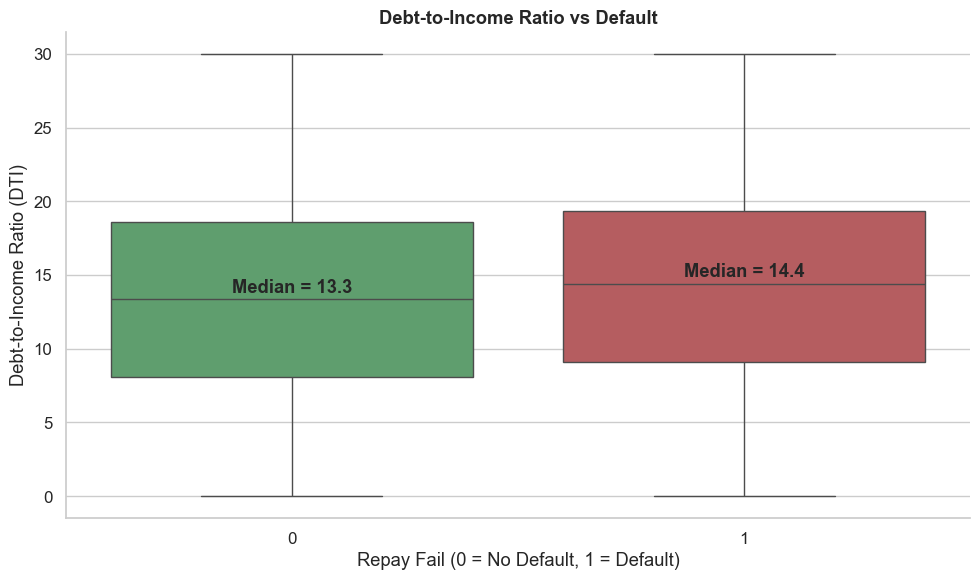

In [33]:
#  Relation between Debt-to-income ratio and Default
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='repay_fail',
    y='dti',
    hue='repay_fail',
    palette={0: "#55A868", 1: "#C44E52"},
    legend=False
)

medians = df_clean.groupby('repay_fail')['dti'].median()
for i, v in medians.items():
    plt.text(i, v + 0.5, f"Median = {v:.1f}", ha='center', fontweight='bold')

plt.title("Debt-to-Income Ratio vs Default", weight="bold")
plt.xlabel("Repay Fail (0 = No Default, 1 = Default)")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.tight_layout()
plt.show()


##  Debt-to-Income Ratio vs Loan Default

The boxplot compares the distribution of debt-to-income (DTI) ratios for defaulted and non-defaulted loans.

### Key Observations
- Defaulted loans exhibit a slightly higher median DTI (≈ 14.4) compared to non-defaulted loans (≈ 13.3).
- This indicates that borrowers with higher debt burdens are more likely to experience repayment failure.
- Although there is considerable overlap between the two distributions, the upward shift in median DTI for defaulters suggests a meaningful association.
- The overlap implies that DTI alone is not a strong standalone predictor but provides valuable information when combined with other features.

### Conclusion
Debt-to-income ratio is an economically relevant feature that contributes to default risk assessment and should be retained for modeling, particularly in combination with other borrower and loan characteristics.


In [34]:
bins = [-1, 6, 24, 60, 998, 1000]
labels = ['Very Recent (≤6m)', 'Recent (6–24m)', 'Old (2–5y)', 'Very Old (>5y)', 'Never Delinquent']

df_clean['delinq_bucket'] = pd.cut(
    df_clean['mths_since_last_delinq'],
    bins=bins,
    labels=labels
)


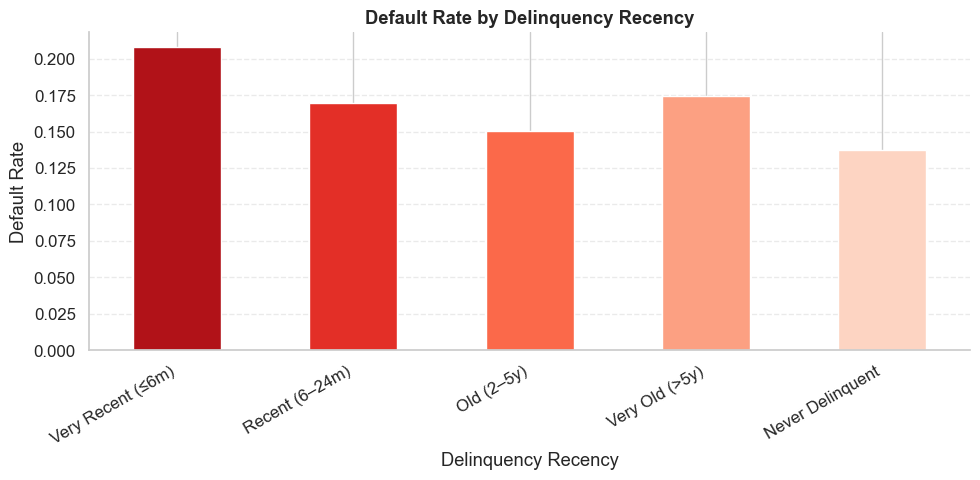

In [35]:
# Relation between recent delinquency and default rate 
delinq_default = (
    df_clean.groupby('delinq_bucket', observed=True)['repay_fail'].mean()

)


plt.figure(figsize=(10,5))
delinq_default.plot(
    kind='bar',
    color=sns.color_palette("Reds", len(delinq_default))[::-1],
    edgecolor="white"
)
plt.title("Default Rate by Delinquency Recency", weight="bold")
plt.xlabel("Delinquency Recency")
plt.ylabel("Default Rate")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## 📊 Default Rate by Delinquency Recency

The bar chart below illustrates how loan default rates vary based on the recency of a borrower’s last delinquency.

### 🔍 Key Observations

- Loans with **very recent delinquency (≤ 6 months)** exhibit the **highest default rate**, indicating elevated short-term credit risk.
- Default risk generally **declines as the time since last delinquency increases**, reflecting improving borrower credit behavior over time.
- Borrowers with **very old delinquency (> 5 years)** show **lower default rates than those with recent delinquencies**, but still higher than borrowers with no delinquency history.
- **Never-delinquent borrowers** have the **lowest default rate**, confirming that the absence of past delinquency is a strong positive credit signal.

### 🧠 Interpretation

The results highlight a **non-linear relationship** between delinquency history and default risk, where **recency matters more than mere occurrence**. Borrowers with any past delinquency remain riskier than those with no history, even if the delinquency occurred several years ago.

### ✅ Conclusion

Delinquency recency is a **highly informative behavioral feature** for credit risk modeling. Separating borrowers who have never been delinquent from those with very old delinquencies preserves important risk distinctions and justifies retaining this variable in the model.


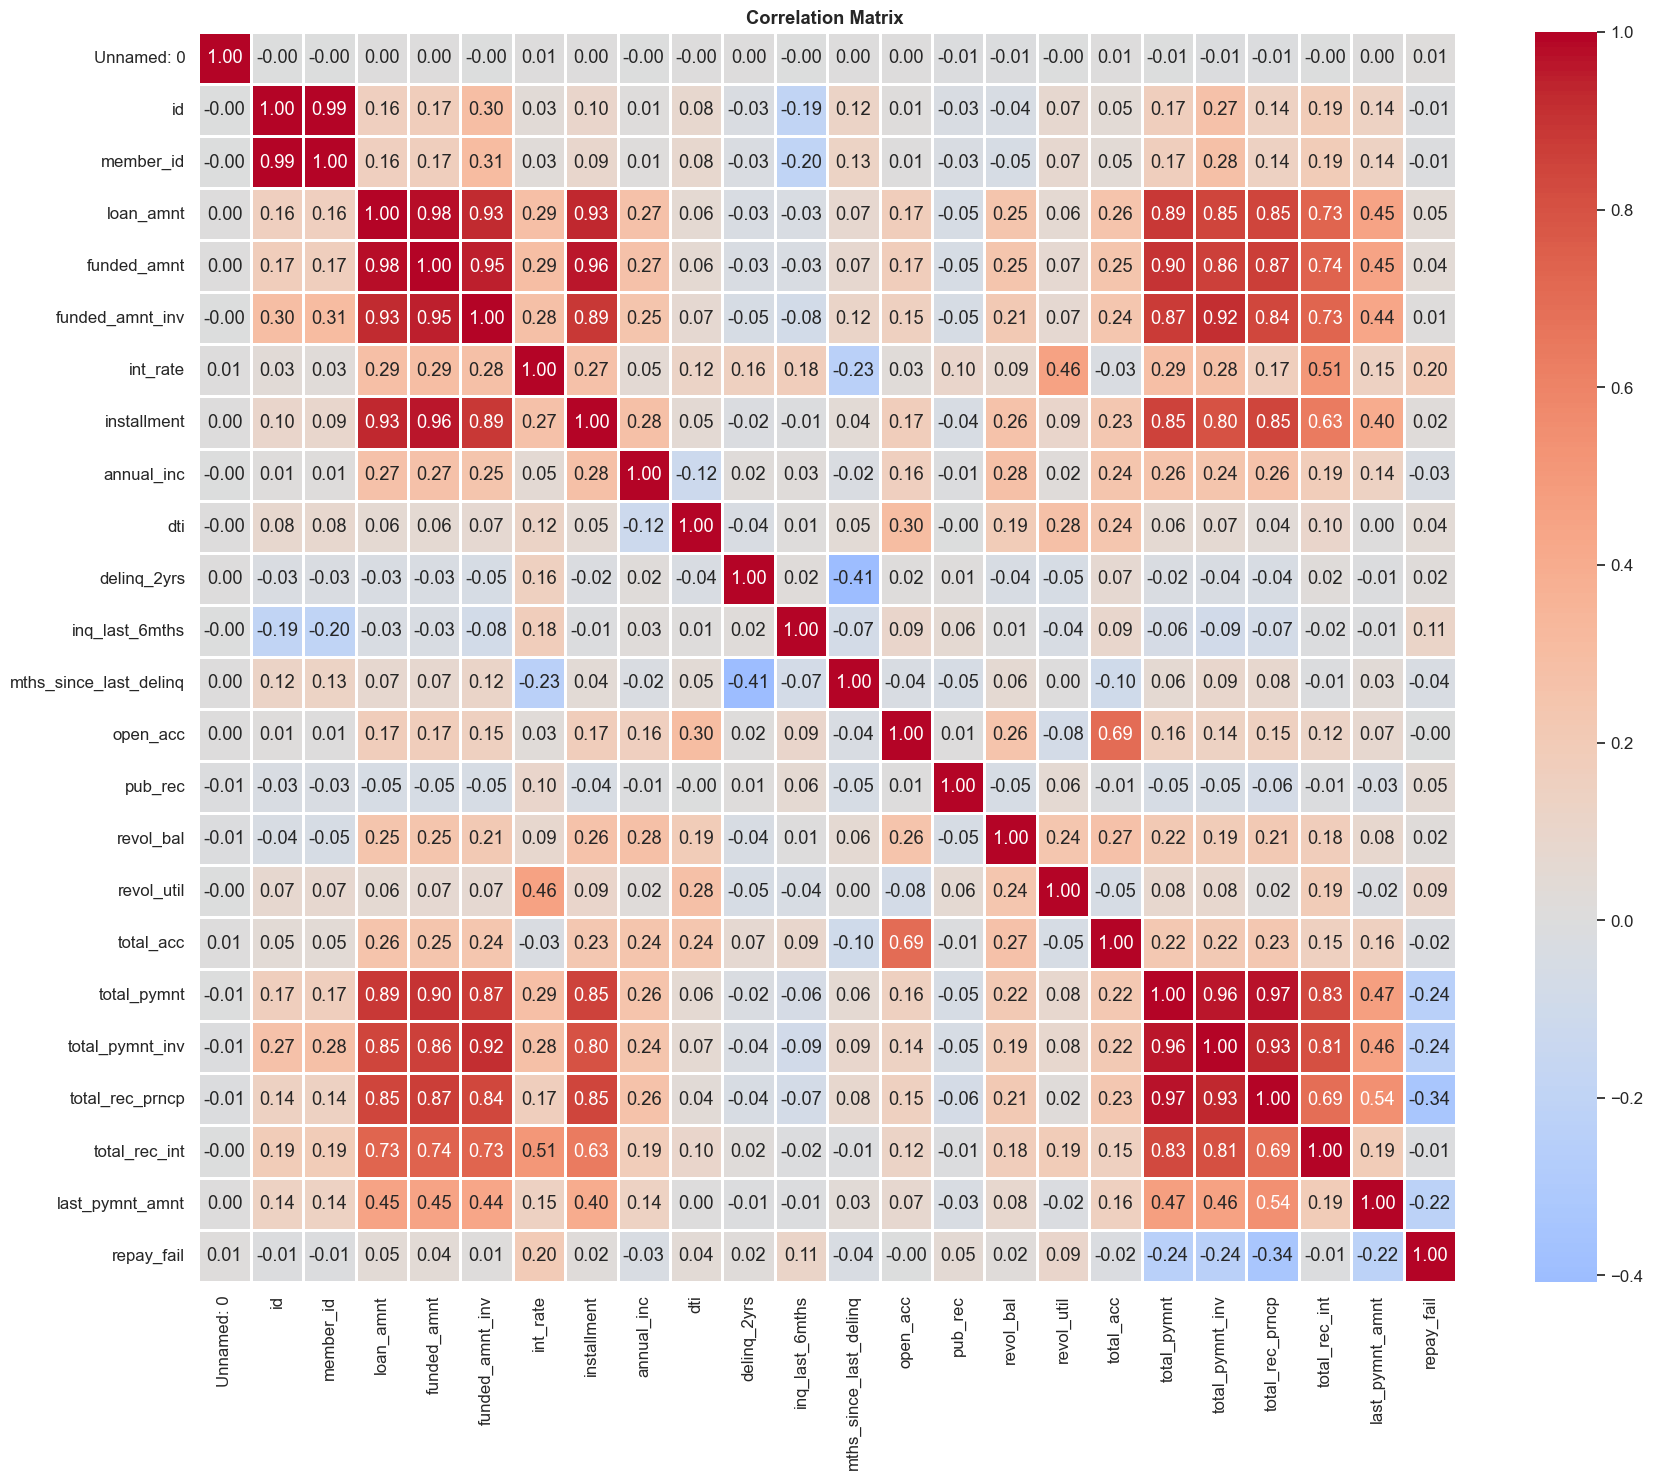

In [36]:
# Correlation between features 
num_features = df_clean.select_dtypes(include=['int64', 'float64'])
target_corr = (
    num_features.corr()['repay_fail']
    .drop('repay_fail')
    .sort_values(key=abs, ascending=False)
)

top_features = target_corr.abs().head(12).index.tolist()
top_features.append('repay_fail')

plt.figure(figsize=(18,15))
sns.heatmap(
    num_features.corr(),
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=.9
)

plt.title("Correlation Matrix ", weight='bold')
plt.tight_layout()
plt.show()


To improve interpretability, the scatter matrix was divided into three logical groups: loan structure, borrower financial health, and credit behavior. This approach preserves all observations while avoiding visual overcrowding and allows clearer inspection of relationships within each feature group.


# Prediction

In [37]:
# Drop identifier columns
drop_cols = [
    'id', 'member_id', 'zip_code', 'addr_state',
    'issue_d', 'earliest_cr_line',
    'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
    'title', 'Unnamed: 0'
]

df_clean.drop(columns=drop_cols, inplace=True, errors='ignore')

df_clean.shape

(37358, 28)

In [38]:
# Clean numeric text columns

# Term (e.g., "36 months" → 36)
df_clean['term'] = (
    df_clean['term']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float)
)

# Employment length (e.g., "10+ years", "< 1 year")
df_clean['emp_length'] = (
    df_clean['emp_length']
    .astype(str)
    .replace('< 1 year', '0')
    .replace('10+ years', '10')
    .str.extract(r'(\d+)')
    .astype(float)
)

# Revolving utilization (e.g., "83%" → 83)
df_clean['revol_util'] = (
    df_clean['revol_util']
    .astype(str)
    .str.replace('%', '', regex=False)
    .replace('nan', np.nan)
    .astype(float)
)



In [39]:
# Remove leakage columns

leakage_cols = [
    'loan_status',
    'funded_amnt',
    'funded_amnt_inv',
    'installment',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'last_pymnt_amnt'
]

df_model = df_clean.drop(columns=leakage_cols, errors='ignore')


print("Target exists:", 'repay_fail' in df_model.columns)
df_model.shape

Target exists: True


(37358, 19)

In [40]:
# Feature Engineering

# Repayment Stress
df_model['loan_to_income'] = df_model['loan_amnt'] / (df_model['annual_inc'] + 1)

# Credit Account Density
df_model['avg_credit_per_account'] = df_model['revol_bal'] / (df_model['open_acc'] + 1)

# Credit Utilization Ratio
df_model['credit_utilization_ratio'] = df_model['revol_util'] / 100

# Recent Delinquency Flag
df_model['recent_delinquency'] = (df_model['mths_since_last_delinq'] <= 12).astype(int)

# Chronic Delinquency Indicator
df_model['chronic_delinquent'] = (
    (df_model['delinq_2yrs'] >= 2) &
    (df_model['mths_since_last_delinq'] <= 36)
).astype(int)

# DTI × Interest Rate Interaction
df_model['dti_int_rate_interaction'] = df_model['dti'] * df_model['int_rate']

# Utilization per Account
df_model['utilization_per_account'] = df_model['revol_bal'] / (df_model['total_acc'] + 1)

# Low Employment Flag
df_model['low_employment'] = (df_model['emp_length'] <= 1).astype(int)

print("Feature Engineering Done")
df_model.shape

Feature Engineering Done


(37358, 27)

In [41]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_model.drop('repay_fail', axis=1)
y = df_model['repay_fail']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps default proportion balanced
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (29886, 26)
Test shape: (7472, 26)


In [42]:
# High Risk Purpose (Leakage-Free)

# Combine X_train and y_train temporarily
train_temp = X_train.copy()
train_temp['repay_fail'] = y_train

# Calculate default rate using ONLY training data
purpose_default_rate = train_temp.groupby('purpose')['repay_fail'].mean()

threshold = purpose_default_rate.mean()

high_risk_purposes = purpose_default_rate[
    purpose_default_rate > threshold
].index.tolist()

print("High Risk Purposes:", high_risk_purposes)

# Add feature to train
X_train['high_risk_purpose'] = X_train['purpose'].apply(
    lambda x: 1 if x in high_risk_purposes else 0
)

# Add feature to test (using same list)
X_test['high_risk_purpose'] = X_test['purpose'].apply(
    lambda x: 1 if x in high_risk_purposes else 0
)

print("High Risk Feature Added")

High Risk Purposes: ['educational', 'house', 'medical', 'moving', 'other', 'renewable_energy', 'small_business']
High Risk Feature Added


In [43]:
# One-Hot Encoding (after split)

# Identify categorical columns (object + category)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns:", cat_cols)

# One-hot encode
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align train & test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Encoding completed successfully.")

Categorical columns: ['home_ownership', 'verification_status', 'purpose', 'delinq_bucket']
Encoding completed successfully.


In [44]:
# Check missing values in df_model
df_model.isnull().sum().sort_values(ascending=False).head(10)

loan_amnt                   0
revol_bal                   0
utilization_per_account     0
dti_int_rate_interaction    0
chronic_delinquent          0
recent_delinquency          0
credit_utilization_ratio    0
avg_credit_per_account      0
loan_to_income              0
delinq_bucket               0
dtype: int64

In [45]:
# Generate descriptive statistics for 'mths_since_last_delinq'
df_model['mths_since_last_delinq'].describe()

count    37358.000000
mean       643.984207
std        465.203161
min          0.000000
25%         45.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: mths_since_last_delinq, dtype: float64

In [46]:
# Create a new binary feature: 'chronic_delinquent'
df_model['chronic_delinquent'] = (
    (df_model['delinq_2yrs'] >= 2) &
    (df_model['mths_since_last_delinq'] <= 36)
).astype(int)

In [47]:
# Check distribution of the newly created feature 'chronic_delinquent'
df_model['chronic_delinquent'].value_counts(normalize=True)

chronic_delinquent
0    0.972991
1    0.027009
Name: proportion, dtype: float64

In [48]:
# Calculate default rate based on chronic delinquency status
df_model.groupby('chronic_delinquent')['repay_fail'].mean()

chronic_delinquent
0    0.146717
1    0.189296
Name: repay_fail, dtype: float64

In [49]:
# STEP 1: Feature Scaling
# Logistic Regression is sensitive to feature magnitudes.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling successful.")

Scaling successful.


In [50]:
# --------------------------------------------------
# Logistic Regression (Improved for Imbalance)
# --------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Initialize model with class balancing
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'   # 🔥 Important change
)

# Train on scaled data
log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Trained Successfully")

# Evaluation
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba_log))

Logistic Regression Trained Successfully

Confusion Matrix:
 [[4132 2235]
 [ 387  718]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.65      0.76      6367
           1       0.24      0.65      0.35      1105

    accuracy                           0.65      7472
   macro avg       0.58      0.65      0.56      7472
weighted avg       0.82      0.65      0.70      7472


ROC-AUC Score: 0.7087706905018595


In [51]:
# --------------------------------------------------
# Random Forest
# --------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=600,        # more trees
    max_depth=12,            # controlled depth
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight={0:1, 1:3},  # stronger penalty to minority class
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Improved Random Forest Trained")
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Improved Random Forest Trained
ROC-AUC: 0.7043738678010983


In [52]:
import numpy as np
from sklearn.metrics import classification_report

threshold = 0.30

y_pred_rf_adj = (y_proba_rf >= threshold).astype(int)

print("Random Forest (Threshold = 0.30)\n")
print(classification_report(y_test, y_pred_rf_adj))

Random Forest (Threshold = 0.30)

              precision    recall  f1-score   support

           0       0.92      0.61      0.74      6367
           1       0.23      0.68      0.35      1105

    accuracy                           0.62      7472
   macro avg       0.58      0.65      0.54      7472
weighted avg       0.82      0.62      0.68      7472



In [53]:
# Calculate scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 5.76306856754922


In [54]:
# --------------------------------------------------
# XGBoost
# --------------------------------------------------

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,  # 🔥 important
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Trained Successfully")

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Trained Successfully

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.71      0.80      6367
           1       0.26      0.56      0.35      1105

    accuracy                           0.69      7472
   macro avg       0.58      0.64      0.58      7472
weighted avg       0.81      0.69      0.73      7472



In [55]:
# Check ROC-AUC scores for different models
from sklearn.metrics import roc_auc_score

print("ROC-AUC Scores:")
print("Logistic Regression:", roc_auc_score(y_test, y_proba_log))
print("Random Forest:", roc_auc_score(y_test, y_proba_rf))
print("XGBoost:", roc_auc_score(y_test, y_proba_xgb))

ROC-AUC Scores:
Logistic Regression: 0.7087706905018595
Random Forest: 0.7043738678010983
XGBoost: 0.6950541785379507


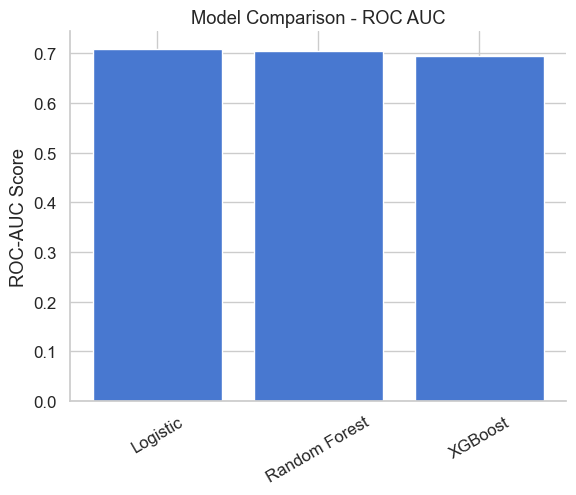

In [57]:
# comparision Of ROC AUC Score of all models using chart 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

models = ["Logistic", "Random Forest", "XGBoost"]

roc_scores = [
    roc_auc_score(y_test, y_proba_log),
    roc_auc_score(y_test, y_proba_rf),
    roc_auc_score(y_test, y_proba_xgb)
]

plt.figure()
plt.bar(models, roc_scores)
plt.title("Model Comparison - ROC AUC")
plt.ylabel("ROC-AUC Score")
plt.xticks(rotation=30)
plt.show()

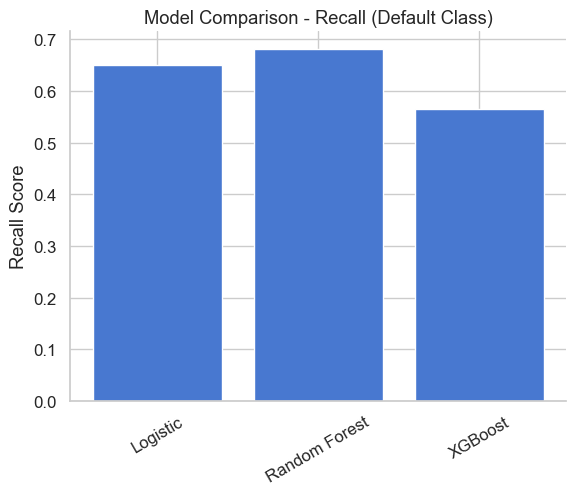

In [58]:
# comparision Of Recall Score of all models using chart 
from sklearn.metrics import recall_score

recall_scores = [
    recall_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_rf_adj),   # adjusted RF threshold
    recall_score(y_test, y_pred_xgb)
]

plt.figure()
plt.bar(models, recall_scores)
plt.title("Model Comparison - Recall (Default Class)")
plt.ylabel("Recall Score")
plt.xticks(rotation=30)
plt.show()

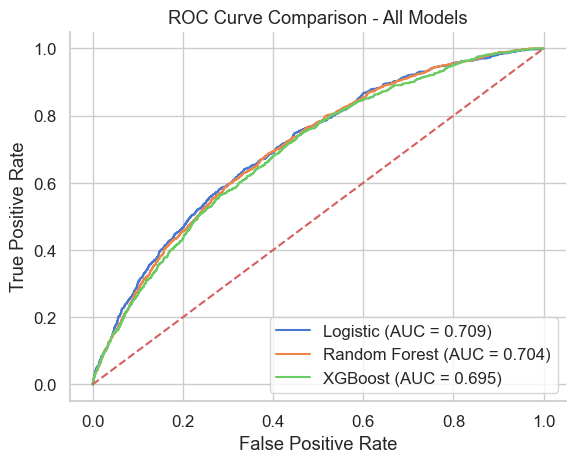

In [59]:
# --------------------------------------------------
# ROC Curve Overlay - All Models
# --------------------------------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# Compute AUC scores
auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

# Plot
plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")
plt.legend()
plt.show()

In [60]:
# Create decision dataframe from test set

decision_df = pd.DataFrame({
    'actual_default': y_test,
    'default_probability': y_proba_log
})

def approval_decision(p):
    if p <= 0.30:
        return 'Approve'
    elif p <= 0.55:
        return 'Manual Review'
    else:
        return 'Reject'

decision_df['approval_decision'] = decision_df['default_probability'].apply(approval_decision)

decision_df.head()


,actual_default,default_probability,approval_decision
21776,0,0.257488,Approve
30429,0,0.309805,Manual Review
6549,0,0.264311,Approve
26092,0,0.449852,Manual Review
27392,1,0.575187,Reject


In [61]:
decision_df['approval_decision'].value_counts(normalize=True)


approval_decision
Manual Review    0.488758
Reject           0.301392
Approve          0.209850
Name: proportion, dtype: float64

In [62]:
pd.crosstab(
    decision_df['approval_decision'],
    decision_df['actual_default'],
    normalize='index'
)

actual_default,0,1
approval_decision,,
Approve,0.961097,0.038903
Manual Review,0.881709,0.118291
Reject,0.728242,0.271758


In [63]:
# --------------------------------------------------
# Risk-Based Interest Rate Calculation
# --------------------------------------------------

BASE_FUNDING_COST = 6.0
TARGET_MARGIN = 3.0
LGD = 0.50   # 60% loss if default

# Expected Loss
decision_df['expected_loss'] = decision_df['default_probability'] * LGD * 100

# Final Interest Rate
decision_df['final_interest_rate'] = (
    BASE_FUNDING_COST +
    TARGET_MARGIN +
    decision_df['expected_loss']
)
MAX_RATE = 35.0

decision_df['final_interest_rate'] = (
    BASE_FUNDING_COST +
    TARGET_MARGIN +
    decision_df['expected_loss']
).clip(upper=MAX_RATE)

decision_df[['default_probability', 'final_interest_rate']].head()

,default_probability,final_interest_rate
21776,0.257488,21.874377
30429,0.309805,24.490241
6549,0.264311,22.215559
26092,0.449852,31.492604
27392,0.575187,35.000000


In [64]:
decision_df.groupby('approval_decision')['final_interest_rate'].mean()


approval_decision
Approve          20.440053
Manual Review    30.132013
Reject           35.000000
Name: final_interest_rate, dtype: float64

In [65]:
# Attach requested loan amount from original dataset

decision_df['requested_loan_amount'] = df_model.loc[X_test.index, 'loan_amnt'].values

In [66]:
decision_df.columns

Index(['actual_default', 'default_probability', 'approval_decision',
       'expected_loss', 'final_interest_rate', 'requested_loan_amount'],
      dtype='object')

In [67]:
# --------------------------------------------------
# SAFE LOAN AMOUNT CALCULATION
# --------------------------------------------------

LGD = 0.60
MAX_LOSS_RATIO = 0.05   # Allowable loss = 5% of annual income

# Attach income from original dataset
decision_df['annual_income'] = df_model.loc[X_test.index, 'annual_inc'].values

# Calculate safe loan amount
decision_df['safe_loan_amount'] = (
    MAX_LOSS_RATIO * decision_df['annual_income']
) / (decision_df['default_probability'] * LGD + 1e-6)

# Final approved loan = minimum of requested and safe amount
decision_df['approved_loan_amount'] = decision_df[[
    'requested_loan_amount',
    'safe_loan_amount'
]].min(axis=1)

decision_df[['default_probability',
             'requested_loan_amount',
             'safe_loan_amount',
             'approved_loan_amount']].head()

,default_probability,requested_loan_amount,safe_loan_amount,approved_loan_amount
21776,0.257488,3000.0,12944.231937,3000.000000
30429,0.309805,9475.0,20173.884208,9475.000000
6549,0.264311,10000.0,18286.410745,10000.000000
26092,0.449852,20000.0,8891.778684,8891.778684
27392,0.575187,5000.0,2173.198306,2173.198306


# Dashboard Data extraction 

In [68]:
decision_df.to_csv("decision_data.csv", index=False)

In [69]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC_AUC": [0.7087, 0.6892, 0.7040],   # replace with your exact values
    "Recall_Default": [0.65, 0.01, 0.56],  # replace with actual
})

model_comparison.to_csv("model_comparison.csv", index=False)

In [70]:
# Get feature names (after encoding & scaling)
feature_names = X_train.columns

# Get coefficients from trained logistic model
coefficients = log_model.coef_[0]

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Importance": abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Absolute_Importance", ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Importance
2,int_rate,0.519372,0.519372
14,loan_to_income,0.309210,0.309210
0,loan_amnt,-0.241593,0.241593
7,inq_last_6mths,0.224629,0.224629
19,dti_int_rate_interaction,-0.220733,0.220733
43,delinq_bucket_Old (2–5y),-0.220371,0.220371
1,term,0.209021,0.209021
5,dti,0.207601,0.207601
6,delinq_2yrs,-0.193972,0.193972
11,revol_bal,0.156701,0.156701


In [71]:
feature_importance.to_csv("feature_importance.csv", index=False)

In [72]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.to_csv("xgb_feature_importance.csv", index=False)